### **Data Exploration**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
dataset = pd.read_csv('pokemon.csv')
dataset.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


Fazer descricao do dataset... e pq escolhemos.


| Column | Description |
| :--- | :--- |
| **Name** | The name of the Pokemon |
| **Type 1** | Primary type (e.g., Fire, Water, Grass) |
| **Type 2** | Secondary type, if any |
| **Total** | Sum of all base stats |
| **HP** | Hit points / Health of the Pokemon |
| **Attack** | Physical attack power |
| **Defense** | Physical defense strength |
| **Sp. Atk** | Special attack power |
| **Sp. Def** | Special defense strength |
| **Speed** | Speed stat |
| **Generation** | The generation of Pokemon (1-8) |
| **Legendary** | Boolean flag indicating if the Pokemon is legendary |

In [4]:

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

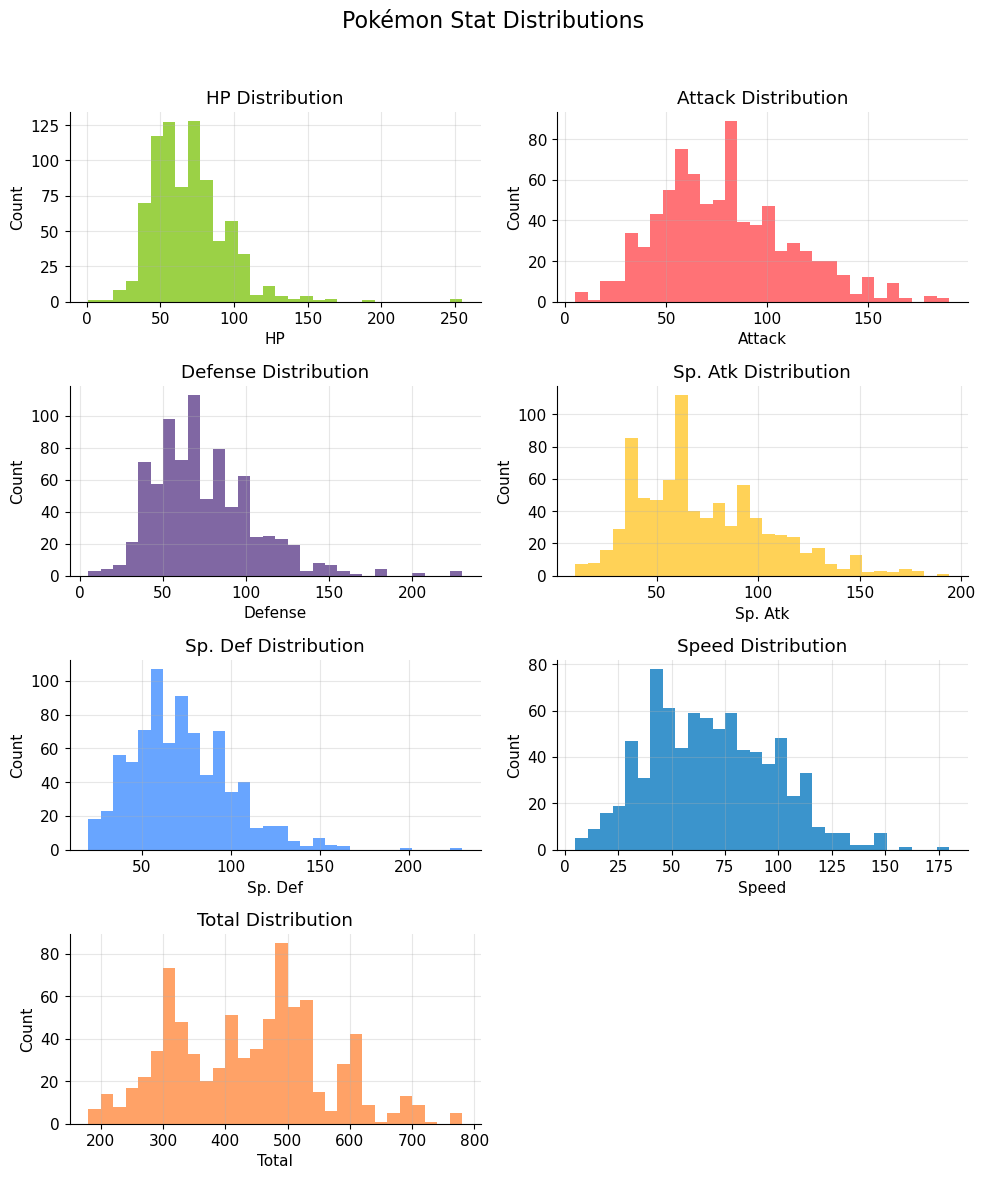

In [8]:
stats = [
    "HP",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed",
    "Total"
]


stat_colors = {
    "HP": "#8AC926",        # green
    "Attack": "#FF595E",    # red
    "Defense": "#6A4C93",   # purple
    "Sp. Atk": "#FFCA3A",    # yellow
    "Sp. Def": "#4D96FF",    # blue
    "Speed": "#1982C4",     # darker blue
    "Total": "#FF924C"      # orange
}

n_stats = len(stats)
n_cols = 2
n_rows = int(np.ceil(n_stats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3 * n_rows))
axes = axes.flatten()

# ----------------------------
# Plot histograms
# ----------------------------
for i, stat in enumerate(stats):
    axes[i].hist(
        dataset[stat],
        bins=30,
        color=stat_colors[stat],
        alpha=0.85
    )
    axes[i].set_title(f"{stat} Distribution")
    axes[i].set_xlabel(stat)
    axes[i].set_ylabel("Count")

# ----------------------------
# Hide unused axes
# ----------------------------
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# ----------------------------
# Aesthetic cleanup
# ----------------------------
for ax in axes[:n_stats]:
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Pokémon Stat Distributions", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

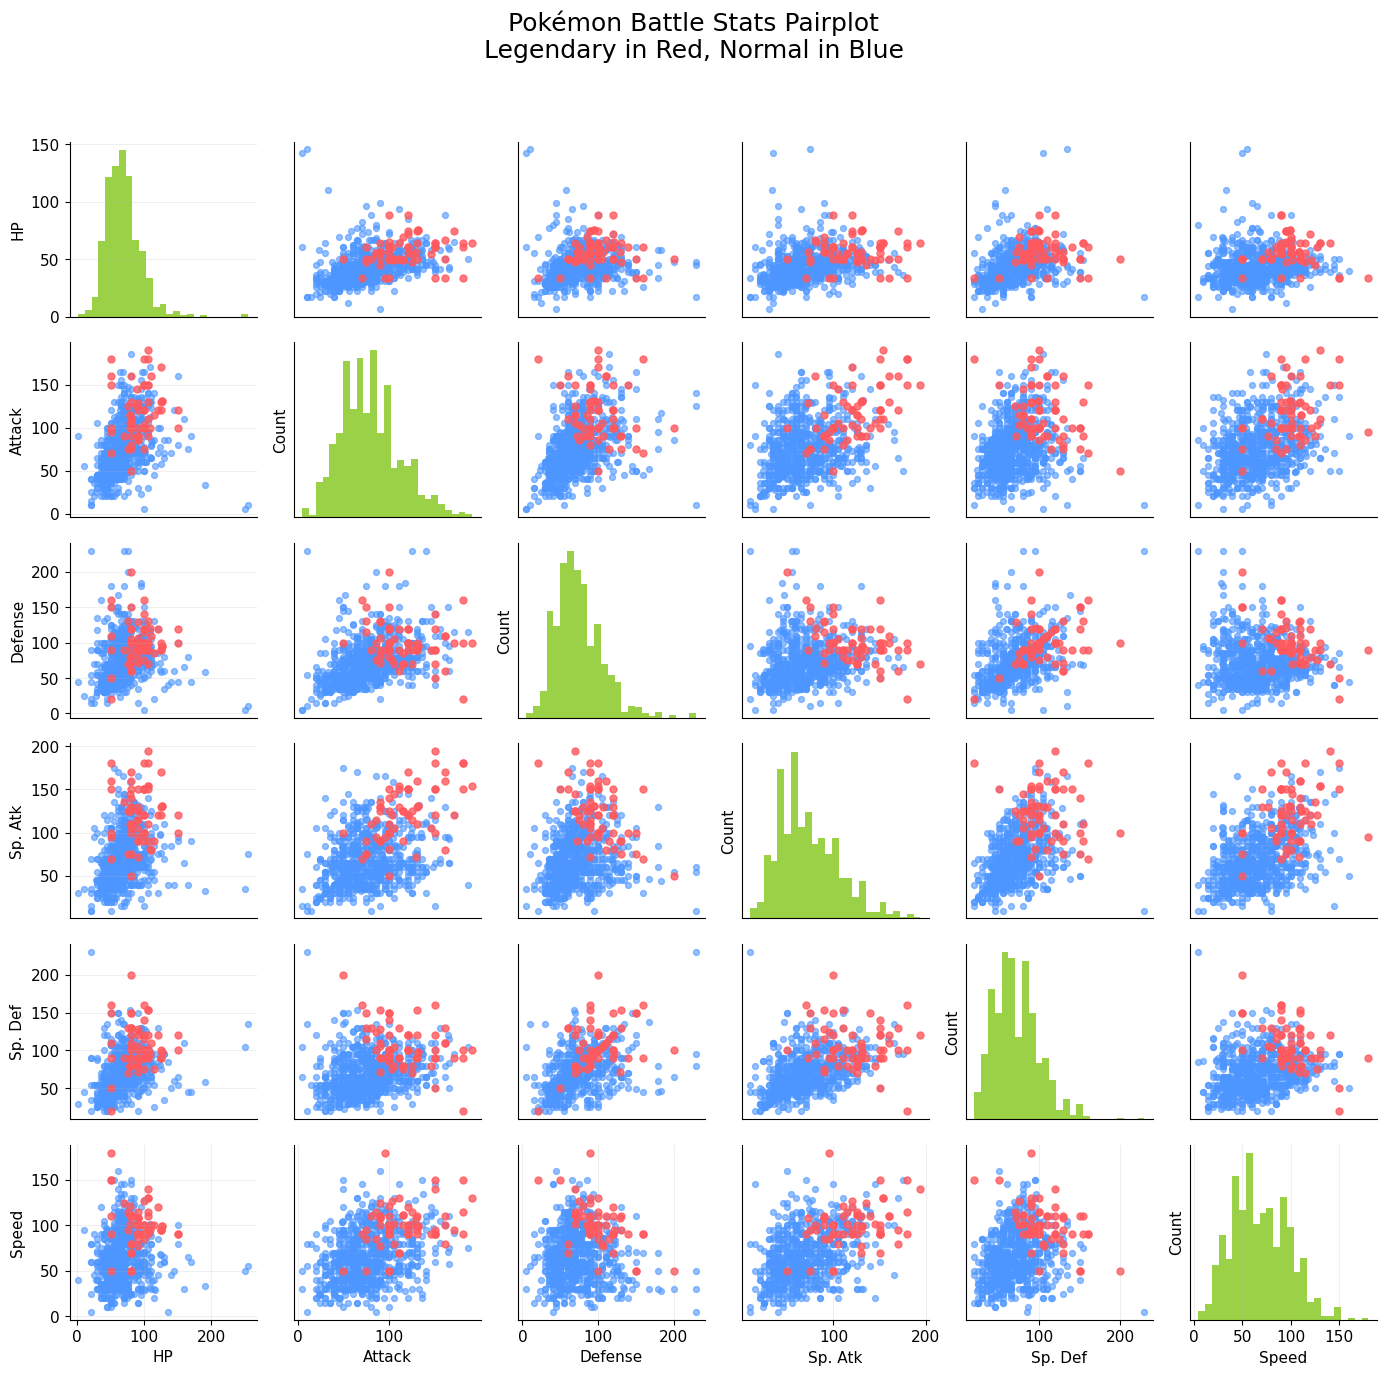

In [11]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

n = len(stats)

# Colors
color_normal = "#4D96FF"     # blue
color_legend = "#FF595E"     # red

fig, axes = plt.subplots(n, n, figsize=(14, 14))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i == j:
            # Diagonal: histogram
            ax.hist(
                dataset[stats[i]],
                bins=25,
                color="#8AC926",
                alpha=0.85
            )
            ax.set_ylabel("Count")

        else:
            # Off-diagonal: scatter
            ax.scatter(
                dataset.loc[~dataset["Legendary"], stats[j]],
                dataset.loc[~dataset["Legendary"], stats[i]],
                s=18,
                alpha=0.6,
                color=color_normal
            )

            ax.scatter(
                dataset.loc[dataset["Legendary"], stats[j]],
                dataset.loc[dataset["Legendary"], stats[i]],
                s=25,
                alpha=0.8,
                color=color_legend
            )

        # Labeling only outer axes
        if i == n - 1:
            ax.set_xlabel(stats[j])
        else:
            ax.set_xticks([])

        if j == 0:
            ax.set_ylabel(stats[i])
        else:
            ax.set_yticks([])

        # Clean look
        ax.grid(True, alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

# Global title
fig.suptitle(
    "Pokémon Battle Stats Pairplot\nLegendary in Red, Normal in Blue",
    fontsize=18
)

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

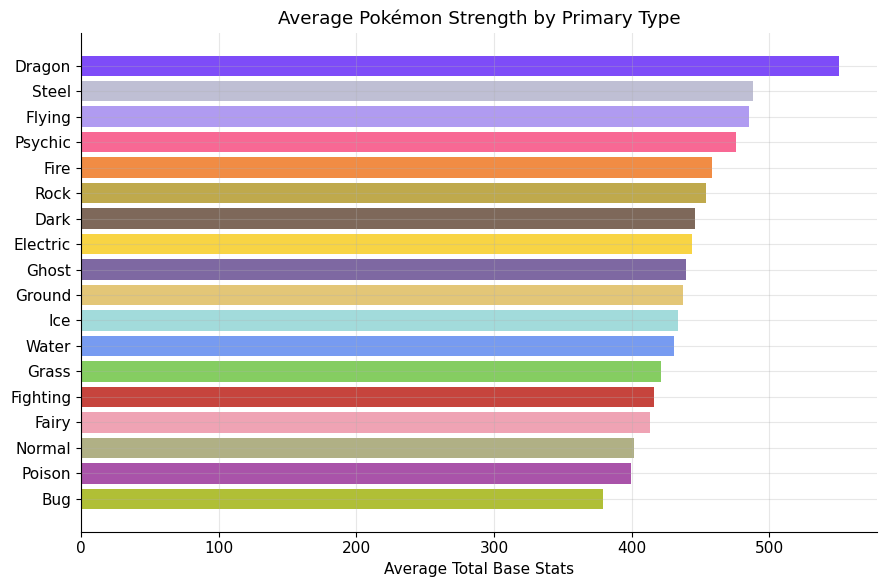

In [13]:

type_means = (
    dataset
    .groupby("Type 1")["Total"]
    .mean()
    .sort_values()
)

# Pokémon-inspired type color map
type_colors = {
    "Grass": "#78C850",
    "Fire": "#F08030",
    "Water": "#6890F0",
    "Electric": "#F8D030",
    "Psychic": "#F85888",
    "Ice": "#98D8D8",
    "Dragon": "#7038F8",
    "Dark": "#705848",
    "Fairy": "#EE99AC",
    "Normal": "#A8A878",
    "Fighting": "#C03028",
    "Flying": "#A890F0",
    "Poison": "#A040A0",
    "Ground": "#E0C068",
    "Rock": "#B8A038",
    "Bug": "#A8B820",
    "Ghost": "#705898",
    "Steel": "#B8B8D0"
}

# Match colors to types (fallback gray if unknown)
bar_colors = [type_colors.get(t, "#999999") for t in type_means.index]

plt.figure(figsize=(9, 6))
plt.barh(type_means.index, type_means.values, color=bar_colors, alpha=0.9)

plt.xlabel("Average Total Base Stats")
plt.title("Average Pokémon Strength by Primary Type")

# Clean look
ax = plt.gca()
ax.grid(True, axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

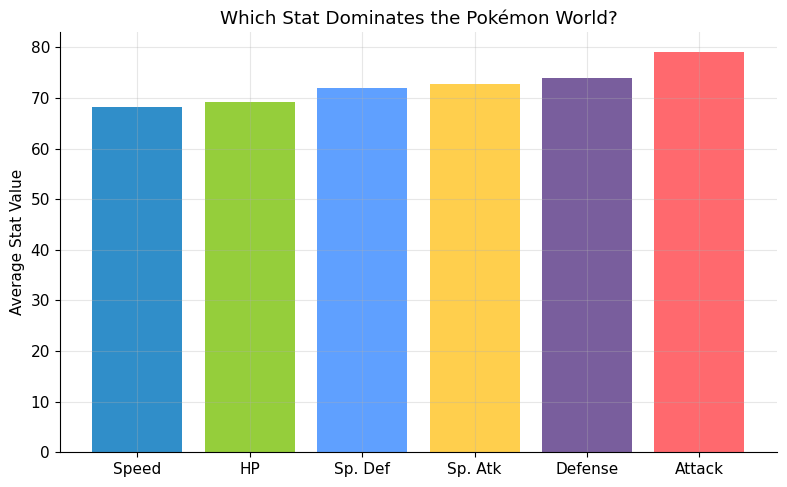

In [18]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

# Compute means
stat_means = dataset[stats].mean().sort_values()

# Pokémon-inspired colors per stat
stat_colors = {
    "HP": "#8AC926",        # green
    "Attack": "#FF595E",    # red
    "Defense": "#6A4C93",   # purple
    "Sp. Atk": "#FFCA3A",    # yellow
    "Sp. Def": "#4D96FF",    # blue
    "Speed": "#1982C4"      # dark blue
}

colors = [stat_colors[s] for s in stat_means.index]

plt.figure(figsize=(8, 5))
plt.bar(stat_means.index, stat_means.values, color=colors, alpha=0.9)

plt.ylabel("Average Stat Value")
plt.title("Which Stat Dominates the Pokémon World?")

# Clean aesthetic
ax = plt.gca()
ax.grid(True, axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

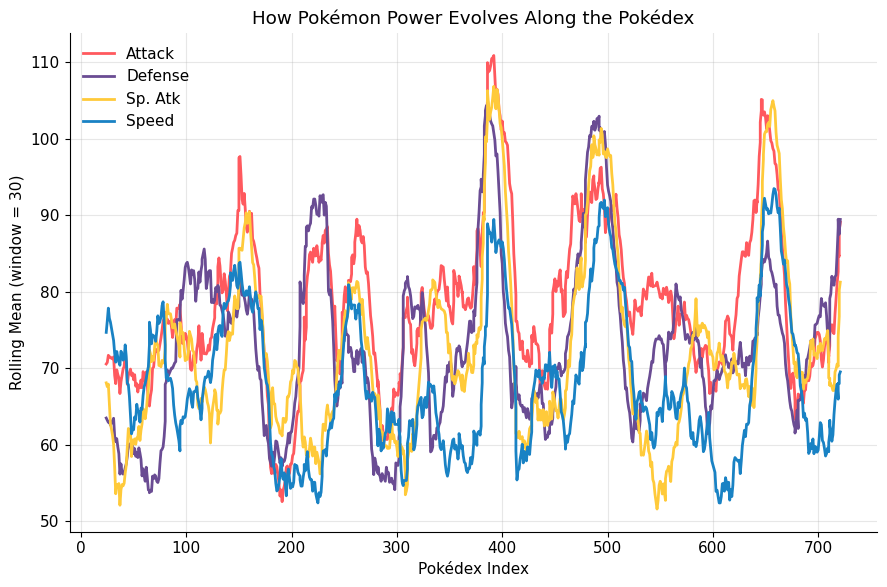

In [20]:

# Sort by Pokédex index
df_sorted = dataset.sort_values("#")

# Stats to track
stats = ["Attack", "Defense", "Sp. Atk", "Speed"]

# Rolling window size
window = 30

# Colors (consistent Pokémon palette)
stat_colors = {
    "Attack": "#FF595E",    # red
    "Defense": "#6A4C93",   # purple
    "Sp. Atk": "#FFCA3A",   # yellow
    "Speed": "#1982C4"      # blue
}

plt.figure(figsize=(9, 6))

# Plot rolling means
for stat in stats:
    rolling_mean = df_sorted[stat].rolling(window=window).mean()
    plt.plot(
        df_sorted["#"],
        rolling_mean,
        label=stat,
        color=stat_colors[stat],
        linewidth=2
    )

plt.xlabel("Pokédex Index")
plt.ylabel(f"Rolling Mean (window = {window})")
plt.title("How Pokémon Power Evolves Along the Pokédex")
plt.legend(frameon=False)

# Clean look
ax = plt.gca()
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

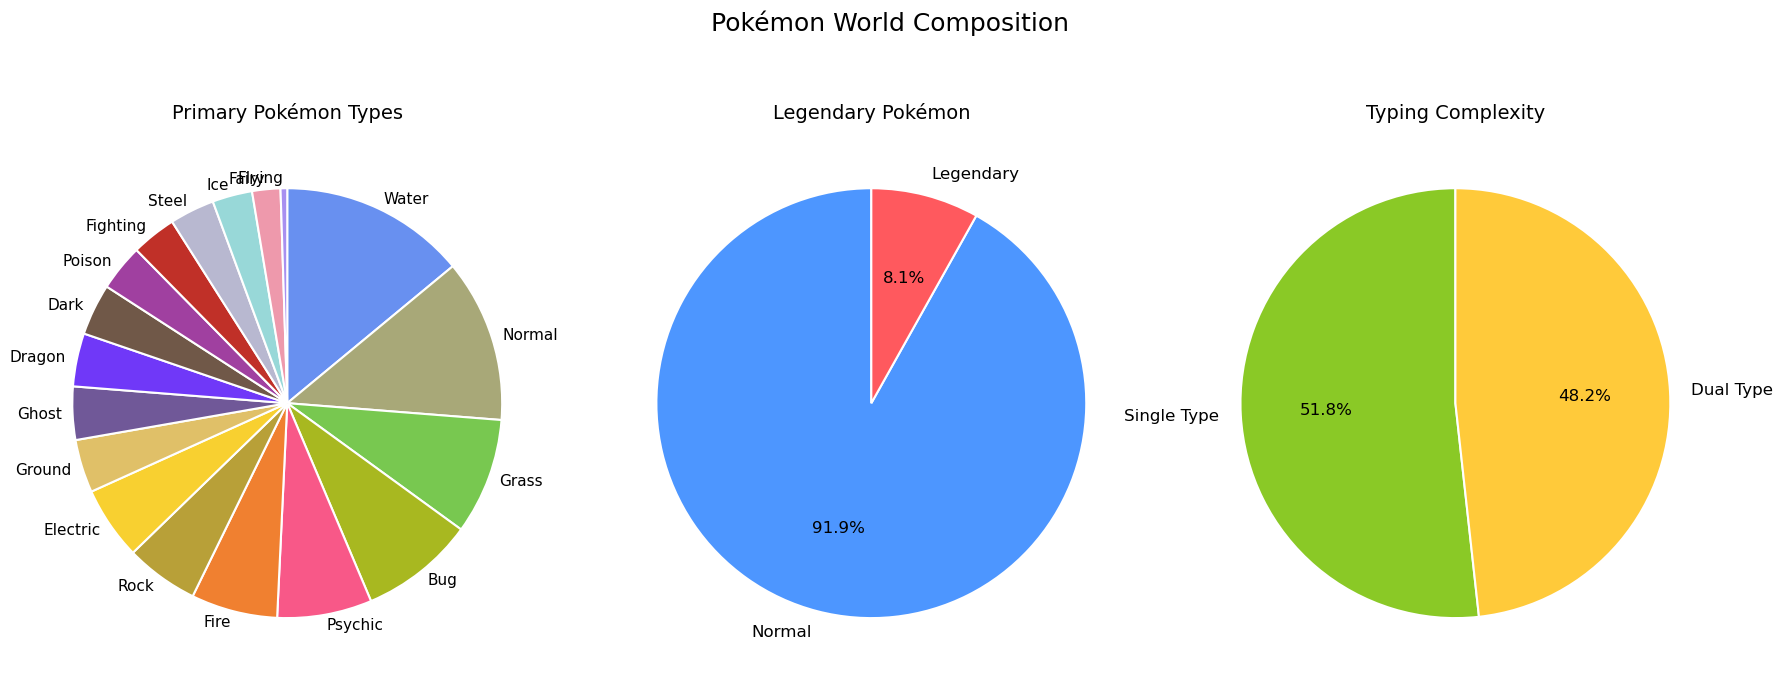

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))  # bigger figure

# Increase space between subplots
fig.subplots_adjust(wspace=0.4)

# -------------------------------------------------
# 1. Primary type distribution
# -------------------------------------------------

type_counts = dataset["Type 1"].value_counts()
type_colors = {
    "Grass": "#78C850", "Fire": "#F08030", "Water": "#6890F0",
    "Electric": "#F8D030", "Psychic": "#F85888", "Ice": "#98D8D8",
    "Dragon": "#7038F8", "Dark": "#705848", "Fairy": "#EE99AC",
    "Normal": "#A8A878", "Fighting": "#C03028", "Flying": "#A890F0",
    "Poison": "#A040A0", "Ground": "#E0C068", "Rock": "#B8A038",
    "Bug": "#A8B820", "Ghost": "#705898", "Steel": "#B8B8D0"
}
colors = [type_colors.get(t, "#999999") for t in type_counts.index]

axes[0].pie(
    type_counts.values,
    labels=type_counts.index,
    colors=colors,
    startangle=90,
    counterclock=False,
    labeldistance=1.05,   # space out labels
    wedgeprops={"edgecolor":"white", "linewidth":1.5}  # sharper wedges
)
axes[0].set_title("Primary Pokémon Types", fontsize=14)

# -------------------------------------------------
# 2. Legendary vs non-Legendary
# -------------------------------------------------

legendary_counts = dataset["Legendary"].value_counts()

axes[1].pie(
    legendary_counts.values,
    labels=["Normal", "Legendary"],
    colors=["#4D96FF", "#FF595E"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize":12},
    wedgeprops={"edgecolor":"white", "linewidth":1.5}
)
axes[1].set_title("Legendary Pokémon", fontsize=14)

# -------------------------------------------------
# 3. Single-type vs Dual-type
# -------------------------------------------------

dual_type = dataset["Type 2"].notna() & (dataset["Type 2"] != "None")
type_mode_counts = dual_type.value_counts()

axes[2].pie(
    type_mode_counts.values,
    labels=["Single Type", "Dual Type"],
    colors=["#8AC926", "#FFCA3A"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize":12},
    wedgeprops={"edgecolor":"white", "linewidth":1.5}
)
axes[2].set_title("Typing Complexity", fontsize=14)

# -------------------------------------------------
# Global aesthetics
# -------------------------------------------------

for ax in axes:
    ax.axis("equal")  # perfect circles

fig.suptitle("Pokémon World Composition", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

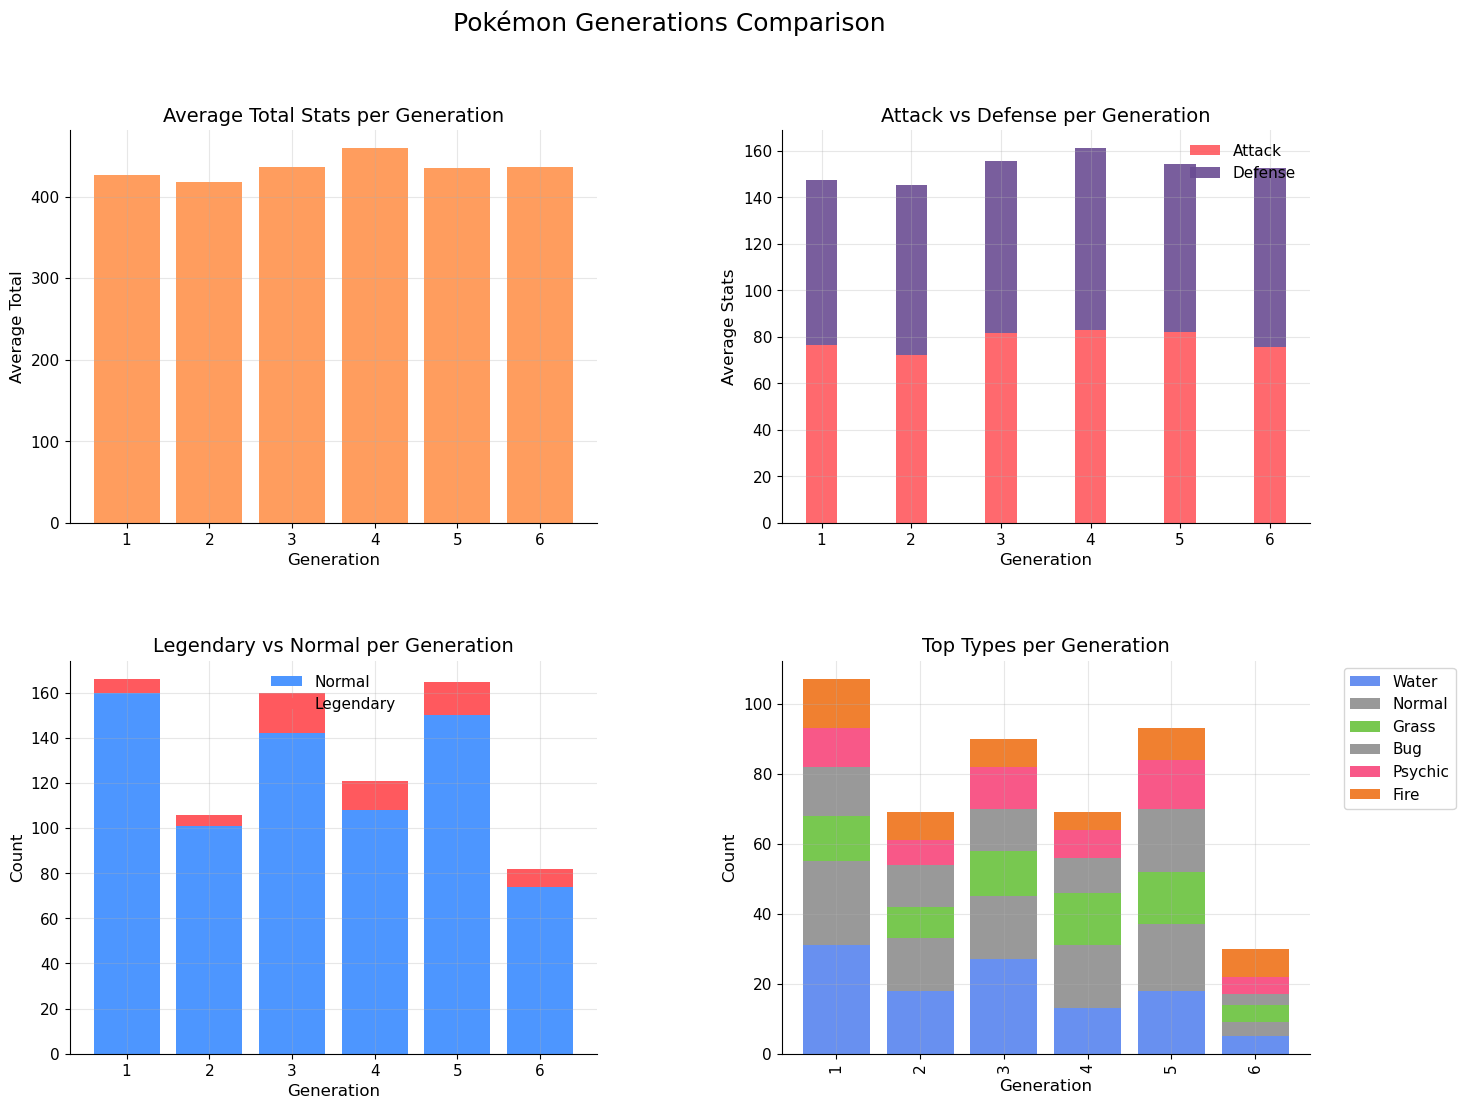

In [30]:
avg_total = dataset.groupby("Generation")["Total"].mean()
avg_attack = dataset.groupby("Generation")["Attack"].mean()
avg_defense = dataset.groupby("Generation")["Defense"].mean()

# Legendary counts per generation
legendary_counts = dataset.groupby("Generation")["Legendary"].sum()
normal_counts = dataset.groupby("Generation")["Legendary"].count() - legendary_counts

# Type counts per generation (top 6 types)
types_per_gen = dataset.groupby(["Generation","Type 1"]).size().unstack(fill_value=0)
top_types = types_per_gen.sum().sort_values(ascending=False).head(6).index
types_per_gen = types_per_gen[top_types]

# Pokémon type colors
type_colors = {
    "Grass": "#78C850", "Fire": "#F08030", "Water": "#6890F0",
    "Electric": "#F8D030", "Psychic": "#F85888", "Ice": "#98D8D8",
}

# ----------------------------
# Create 2x2 subplots
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Adjust space between subplots
fig.subplots_adjust(wspace=0.35, hspace=0.35)

# ----------------------------
# 1. Average Total Stats
# ----------------------------
axes[0].bar(avg_total.index.astype(str), avg_total.values, color="#FF924C", alpha=0.9)
axes[0].set_title("Average Total Stats per Generation", fontsize=14)
axes[0].set_xlabel("Generation", fontsize=12)
axes[0].set_ylabel("Average Total", fontsize=12)
axes[0].grid(axis="y", alpha=0.3)

# ----------------------------
# 2. Average Attack / Defense
# ----------------------------
width = 0.35
x = avg_attack.index.astype(str)
axes[1].bar(x, avg_attack.values, width=width, color="#FF595E", label="Attack", alpha=0.9)
axes[1].bar(x, avg_defense.values, width=width, bottom=avg_attack.values, color="#6A4C93", label="Defense", alpha=0.9)
axes[1].set_title("Attack vs Defense per Generation", fontsize=14)
axes[1].set_xlabel("Generation", fontsize=12)
axes[1].set_ylabel("Average Stats", fontsize=12)
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.3)

# ----------------------------
# 3. Legendary vs Normal
# ----------------------------
axes[2].bar(avg_total.index.astype(str), normal_counts, color="#4D96FF", label="Normal")
axes[2].bar(avg_total.index.astype(str), legendary_counts, bottom=normal_counts, color="#FF595E", label="Legendary")
axes[2].set_title("Legendary vs Normal per Generation", fontsize=14)
axes[2].set_xlabel("Generation", fontsize=12)
axes[2].set_ylabel("Count", fontsize=12)
axes[2].legend(frameon=False)
axes[2].grid(axis="y", alpha=0.3)

# ----------------------------
# 4. Top Types per Generation
# ----------------------------
types_per_gen.plot(
    kind="bar",
    stacked=True,
    ax=axes[3],
    color=[type_colors.get(t, "#999999") for t in types_per_gen.columns],
    width=0.8
)
axes[3].set_title("Top Types per Generation", fontsize=14)
axes[3].set_xlabel("Generation", fontsize=12)
axes[3].set_ylabel("Count", fontsize=12)
axes[3].legend(bbox_to_anchor=(1.05,1), loc="upper left")
axes[3].grid(axis="y", alpha=0.3)

# ----------------------------
# Global title
# ----------------------------
fig.suptitle("Pokémon Generations Comparison", fontsize=18)
plt.show()

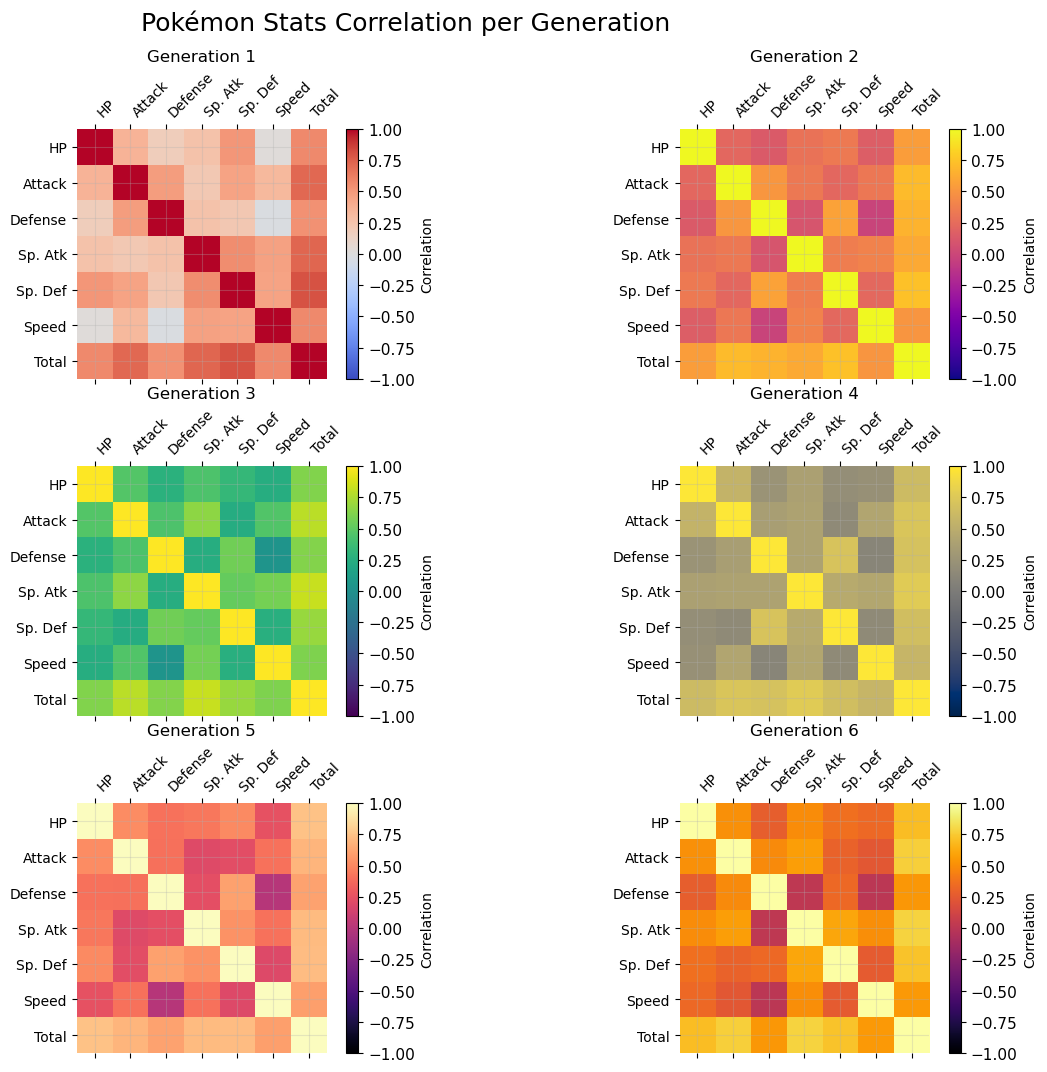

In [32]:
stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Total"]

# All generations
generations = sorted(dataset["Generation"].unique())
n_gen = len(generations)

# Grid size
n_cols = 2
n_rows = int(np.ceil(n_gen / n_cols))

# Funky colormaps
cmaps = [
    "coolwarm", "plasma", "viridis", "cividis",
    "magma", "inferno", "turbo", "cubehelix"
]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

# Loop through generations
for i, gen in enumerate(generations):
    ax = axes[i]
    corr = dataset[dataset["Generation"]==gen][stats].corr()
    
    im = ax.matshow(corr, cmap=cmaps[i % len(cmaps)], vmin=-1, vmax=1)
    
    # Axes labels
    ax.set_xticks(range(len(stats)))
    ax.set_yticks(range(len(stats)))
    ax.set_xticklabels(stats, rotation=45, ha="left", fontsize=10)
    ax.set_yticklabels(stats, fontsize=10)
    
    ax.set_title(f"Generation {gen}", fontsize=12)
    
    # Hide spines for cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Individual colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label("Correlation", fontsize=10)

# Hide empty axes if generations < n_rows*n_cols
for j in range(i+1, len(axes)):
    axes[j].axis("off")

# Adjust spacing: less space between subplots
plt.subplots_adjust(hspace=0.35, wspace=0.25)
fig.suptitle("Pokémon Stats Correlation per Generation", fontsize=18)
plt.show()

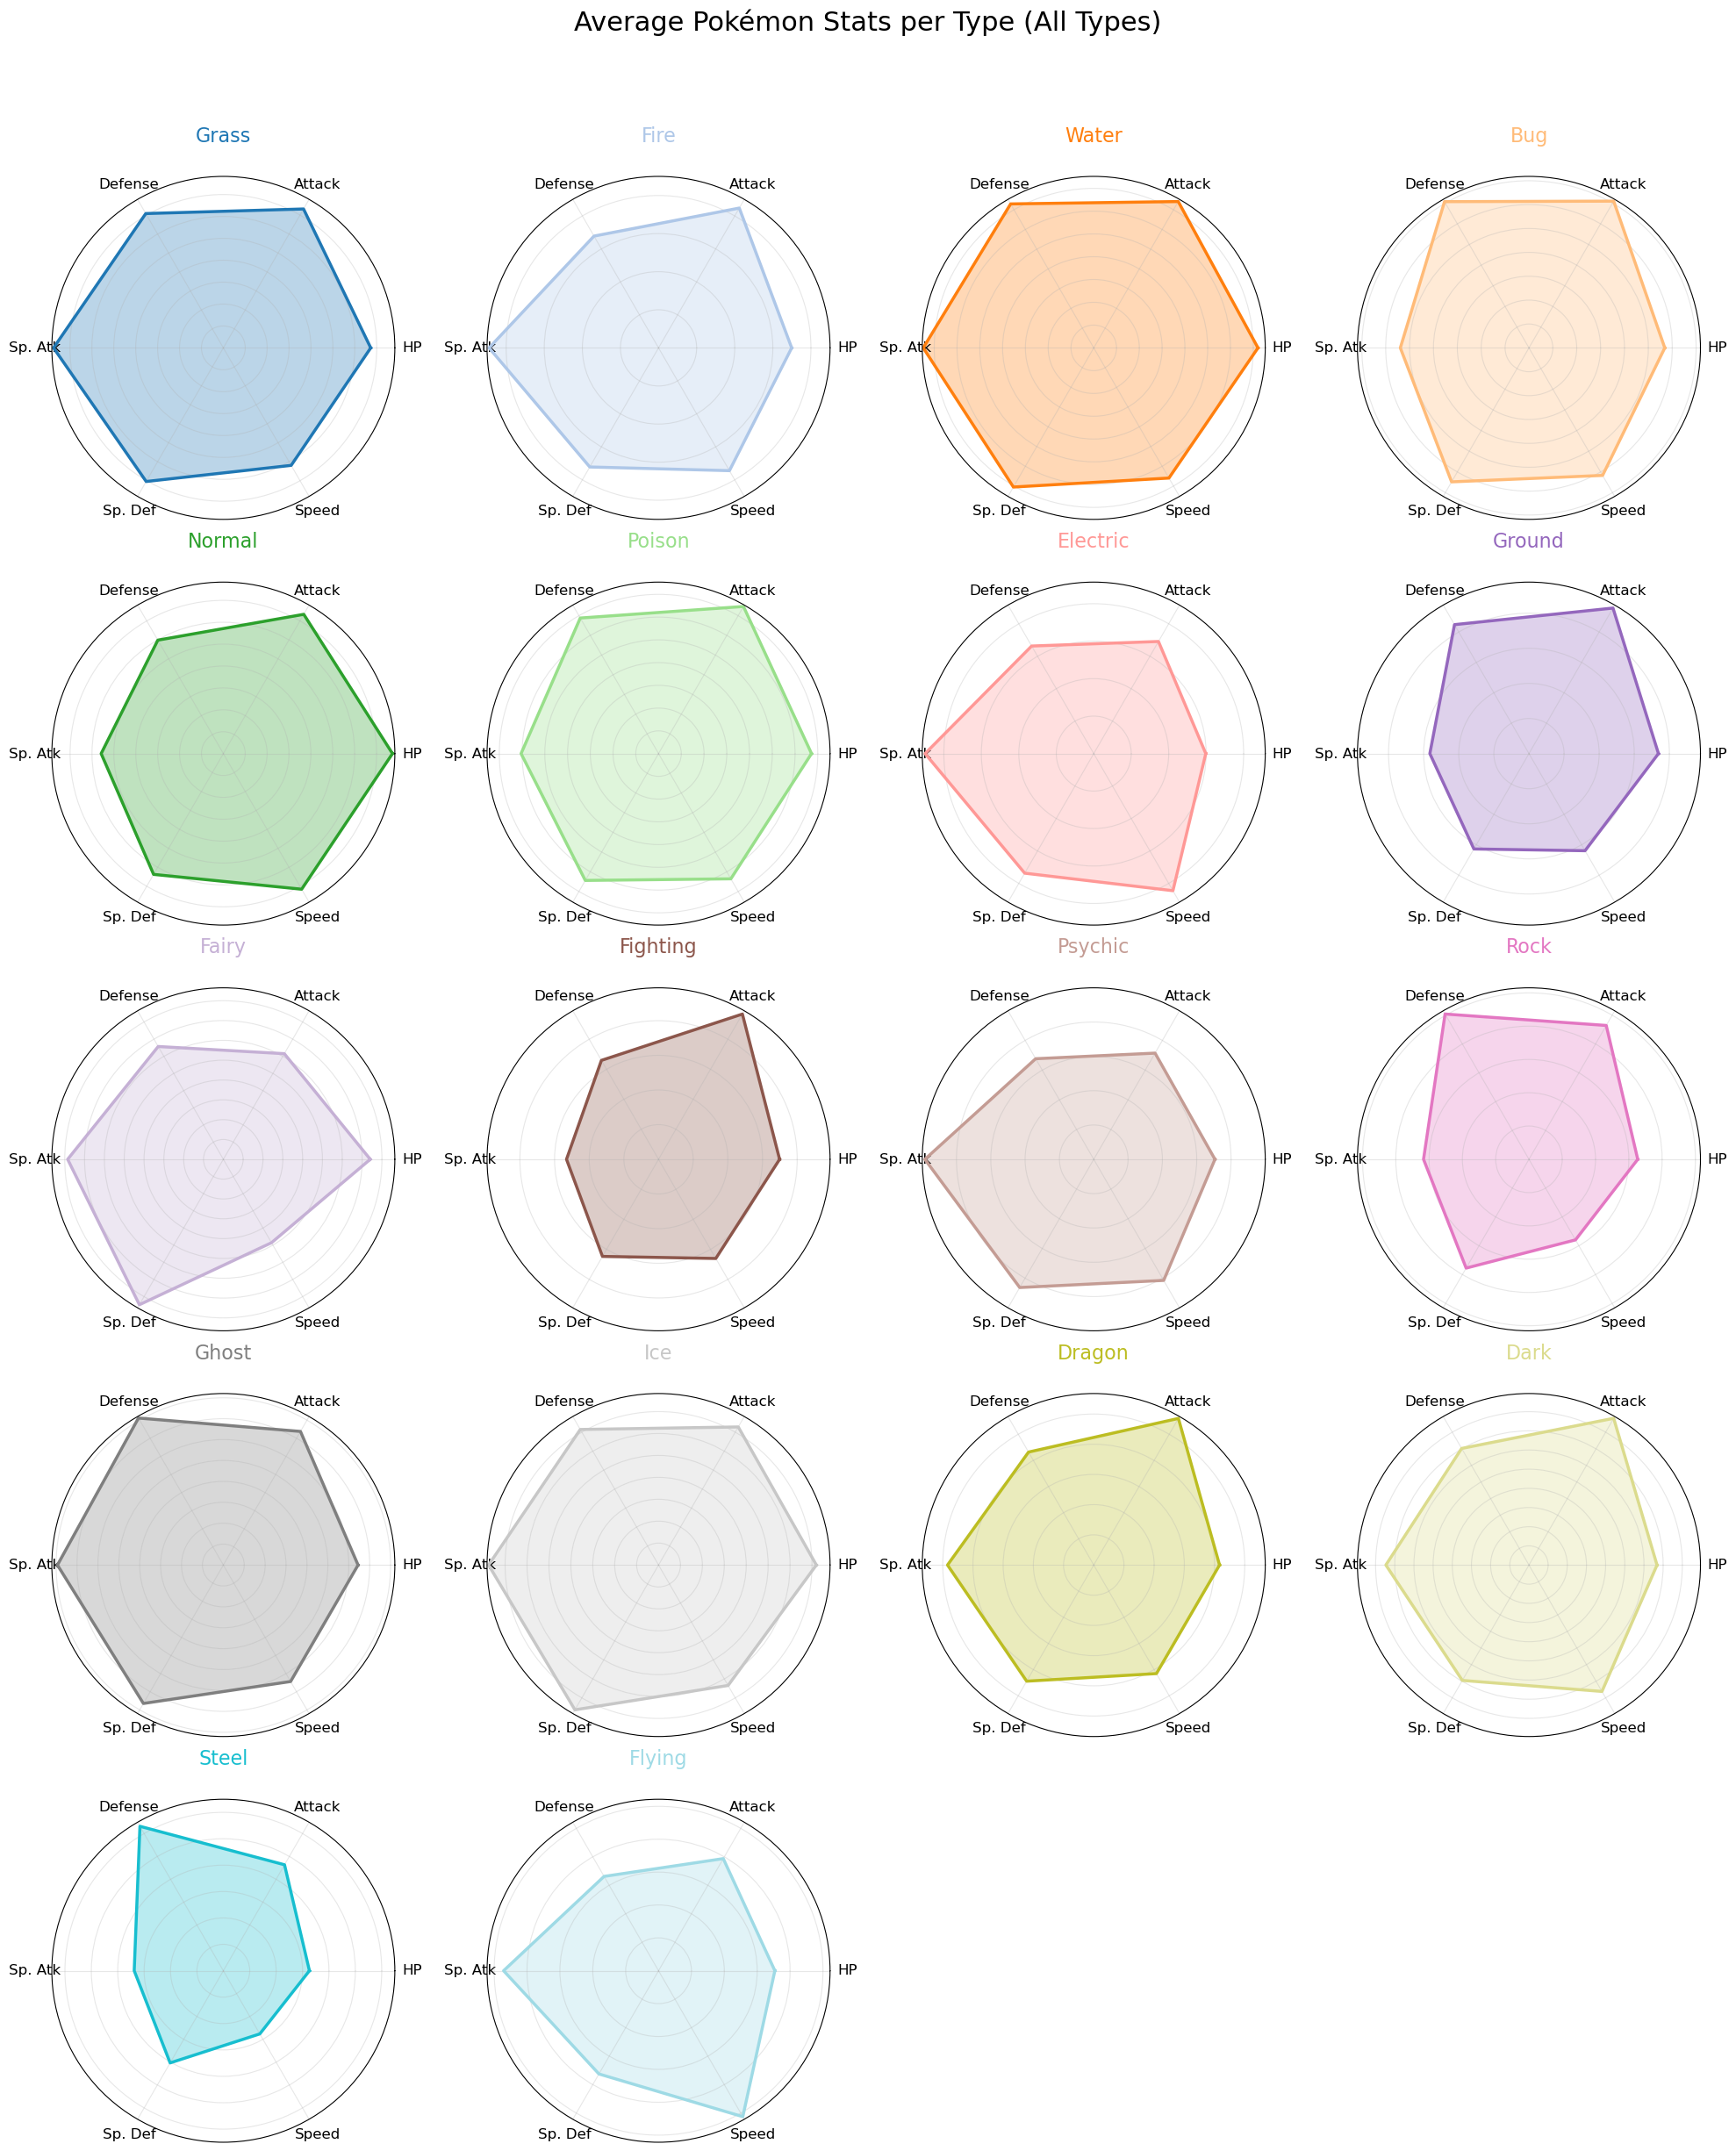

In [34]:
stats = ["HP","Attack","Defense","Sp. Atk","Sp. Def","Speed"]
types = dataset["Type 1"].unique()  # all types

num_stats = len(stats)
angles = np.linspace(0, 2*np.pi, num_stats, endpoint=False).tolist()
angles += angles[:1]  # close the circle

# ----------------------------
# Determine grid size dynamically
# ----------------------------
n_types = len(types)
n_cols = 4
n_rows = int(np.ceil(n_types / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, subplot_kw=dict(polar=True), figsize=(5*n_cols,5*n_rows))
axes = axes.flatten()

colors = plt.cm.tab20(np.linspace(0,1,n_types))  # more colors for all types

# ----------------------------
# Plot each type
# ----------------------------
for ax, t, color in zip(axes, types, colors):
    df_type = dataset[dataset["Type 1"]==t]
    values = df_type[stats].mean().tolist()
    values += values[:1]  # close the circle
    
    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.3)
    
    # Clean axes and bigger fonts
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(stats, fontsize=12)
    ax.set_yticklabels([])
    ax.set_title(t, fontsize=16, color=color, y=1.08)

# Turn off empty subplots if any
for i in range(n_types, len(axes)):
    axes[i].axis('off')

fig.suptitle("Average Pokémon Stats per Type (All Types)", fontsize=22)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()